# NetFlow Deep Learning Classification Lab

This notebook builds a supervised **deep learning** classifier for network flow data (NetFlow/IPFIX-style records).

## Objectives
- Treat each row as a *single network flow record* and learn a model that can **predict the flow’s class**.
- Build an end-to-end pipeline (preprocessing → neural network) that can be reused on new/unseen flows.
- Understand what makes a neural network different from classical ML models (layers, activations, backpropagation).
- Evaluate generalization on a held-out test set using precision/recall/F1 per class.
- Use model-agnostic techniques (permutation importance) to get a rough sense of which fields matter.

## What is “deep learning” in this lab?
In many practical tabular problems, a **deep learning model** is a **multi-layer perceptron (MLP)**: a stack of fully-connected layers that learns non-linear relationships between input features and the target label.

Conceptually:
- The model takes a feature vector $x$ (your flow statistics after preprocessing).
- Each hidden layer computes $h = f(Wx + b)$ where $f$ is a non-linear activation (e.g., ReLU).
- The output layer produces class scores (logits), which are turned into class probabilities (softmax).
- Training uses gradient-based optimization (backpropagation) to minimize a loss function (cross-entropy for multi-class classification).

Why this can help on flow data:
- Flow labels often depend on **feature interactions** (e.g., bytes + packets + duration + port patterns).
- Neural networks can learn smooth, non-linear decision boundaries without manually crafting rules.

Important note:
- For many tabular datasets, tree-based models (Random Forest / Gradient Boosting) can be extremely strong baselines. Deep learning is still useful to learn and to apply when you have larger datasets, additional signals, or when you want a single differentiable model end-to-end.

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

In [7]:
# Optional plotting (the notebook still runs if matplotlib is unavailable)
try:
    import matplotlib.pyplot as plt
    HAS_MPL = True
except Exception as e:
    HAS_MPL = False
    print('Matplotlib not available, skipping plots:', e)

# Optional rich display (works in Jupyter; we fall back to print if missing)
try:
    from IPython.display import display
except Exception:
    display = None

In [8]:
# Load dataset
df = pd.read_csv('flows.csv')  # flows.csv is the NetFlow dataset with a 'Label' column for classification
df = df.dropna(subset=['Label'])  # Drop rows with missing labels
df.head(10)

,SrcPort,DstPort,Protocol,FlowDurationMs,TotFwdPkts,TotBwdPkts,TotLenFwdBytes,TotLenBwdBytes,FlowBytsPerS,FlowPktsPerS,SYNFlagCnt,ACKFlagCnt,RSTFlagCnt,Label
0,25405,443,17,7708.731622,379.0,94.0,210724.0,50384.0,33871.720121,61.358992,0,0,0,VPN
1,55432,8080,6,3024.530486,122.0,1098.0,27084.0,976122.0,331689.829065,403.368392,1,7,1,VIDEO
2,56850,443,6,5081.732696,89.0,44.0,56782.0,34848.0,18031.251441,26.172176,2,6,0,BULK
3,49672,5061,17,5859.682646,308.0,119.0,19404.0,13209.0,5565.659776,72.870841,0,0,0,VOIP
4,50499,443,6,4686.218441,44.0,76.0,16940.0,70072.0,18567.636378,25.607001,1,5,1,WEB
5,33357,443,6,8476.412156,114.0,34.0,126540.0,26894.0,18101.290639,17.460218,2,1,1,BULK
6,15748,443,6,3062.836794,266.0,391.0,139118.0,143106.0,92144.642045,214.507022,0,6,0,VPN
7,39782,443,6,3693.393050,116.0,88.0,30160.0,37840.0,18411.254657,55.233764,2,7,0,VPN
8,64991,443,17,2495.019157,34.0,53.0,2346.0,46163.0,19442.335691,34.869472,0,0,0,WEB
9,48358,1935,6,4272.714279,45.0,637.0,4545.0,348439.0,82613.527832,159.617507,2,5,0,VIDEO


## Data preparation (why preprocessing matters even more for neural networks)

Before training a neural network, we need to convert the flow table into a clean numeric matrix.

The general preprocessing steps are the same as in the supervised ML lab:
- Split columns into **numeric** vs **categorical**.
- **Impute** missing values (median for numeric, most-frequent for categorical) so we do not drop large parts of the dataset.
- One-hot encode categoricals so they become numeric.
- Scale/standardize numeric features.

For deep learning (and other gradient-based models), **scaling is critical**:
- If `TotLenBwdBytes` is in the tens of thousands and another feature is in small units, the large feature can dominate gradients.
- Standardization (zero mean, unit variance) makes optimization more stable and usually speeds up convergence.

We wrap preprocessing + model into a single `Pipeline` so that the *exact same* transformations are applied during both training and evaluation, preventing data leakage and feature mismatches.

In [13]:
# Features and target
features = [col for col in df.columns if col != 'Label']
X = df[features]
y = df['Label']

# Encode labels as integers for the neural network
# (This avoids edge cases when the model internally checks for NaNs/Infs.)
label_encoder = LabelEncoder()
y_enc = pd.Series(label_encoder.fit_transform(y), index=y.index)

# Train/test split (use indices to keep y and y_enc aligned)
train_idx, test_idx = train_test_split(
    df.index, test_size=0.25, stratify=y, random_state=42
)
X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]
y_train_enc, y_test_enc = y_enc.loc[train_idx], y_enc.loc[test_idx]

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]
)

# For MLP, keeping one-hot output dense avoids sparse-matrix edge cases
try:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown='ignore', sparse=False)

categorical_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', onehot)]
)

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ]
)

print('Numeric feature count:', len(numeric_features))
print('Categorical feature count:', len(categorical_features))
numeric_features[:10], categorical_features[:10]

Numeric feature count: 13
Categorical feature count: 0


(['SrcPort',
  'DstPort',
  'Protocol',
  'FlowDurationMs',
  'TotFwdPkts',
  'TotBwdPkts',
  'TotLenFwdBytes',
  'TotLenBwdBytes',
  'FlowBytsPerS',
  'FlowPktsPerS'],
 [])

## Deep learning model: Multi-Layer Perceptron (MLP)

We will use `sklearn.neural_network.MLPClassifier`, which implements a feed-forward neural network trained with backpropagation.

Key hyperparameters you will see below:
- `hidden_layer_sizes`: defines the network depth/width. For example `(128, 64, 32)` means 3 hidden layers.
- `activation='relu'`: ReLU is a common default for hidden layers and helps with optimization.
- `solver='adam'`: Adam is a popular stochastic optimizer for neural networks.
- `alpha`: L2 regularization strength (helps reduce overfitting).
- `early_stopping=True`: automatically reserves a validation split from the training data and stops when validation score stops improving.

Neural networks are flexible but can overfit, especially if the model is large relative to the dataset. Early stopping and regularization are simple, effective safeguards.

In [10]:
mlp = Pipeline(
    steps=[
        ('preprocess', preprocess),
        (
            'model',
            MLPClassifier(
                hidden_layer_sizes=(128, 64, 32),
                activation='relu',
                solver='adam',
                alpha=1e-4,
                batch_size=256,
                learning_rate_init=1e-3,
                max_iter=200,
                early_stopping=True,
                n_iter_no_change=10,
                validation_fraction=0.1,
                random_state=42,
            ),
        ),
    ]
)

mlp.fit(X_train, y_train_enc)
pred_enc = mlp.predict(X_test)
pred = label_encoder.inverse_transform(pred_enc)
print('Deep Learning (MLP) Results')
print(classification_report(y_test, pred))

Deep Learning (MLP) Results
              precision    recall  f1-score   support

        BULK       0.99      1.00      0.99      1857
       VIDEO       0.99      0.99      0.99      2484
        VOIP       1.00      1.00      1.00      1874
         VPN       0.98      0.97      0.98      1921
         WEB       0.99      1.00      1.00      4364

    accuracy                           0.99     12500
   macro avg       0.99      0.99      0.99     12500
weighted avg       0.99      0.99      0.99     12500



In `sklearn.metrics.classification_report`, each row corresponds to one class (a value of `Label`).

The columns mean:
- **precision**: “When the model predicts this class, how often is it correct?”
  $$\text{precision}=\frac{TP}{TP+FP}$$
- **recall**: “Of all the true items of this class, how many did the model find?”
  $$\text{recall}=\frac{TP}{TP+FN}$$
- **f1-score**: harmonic mean of precision and recall.
  $$F_1=\frac{2\cdot(\text{precision}\cdot\text{recall})}{\text{precision}+\text{recall}}$$
- **support**: how many true samples of that class appear in the test set.

For imbalanced datasets, it is common to look at:
- **macro avg** (treat each class equally), and
- **weighted avg** (weight by support).

If you see classes with notably lower recall, that means the model is missing many examples of that class (false negatives).

In [11]:
# Confusion matrix: where does the model get confused?
labels = sorted(y.unique())
cm = confusion_matrix(y_test, pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
(display(cm_df) if display is not None else cm_df)

,BULK,VIDEO,VOIP,VPN,WEB
BULK,1848,0,0,8,1
VIDEO,0,2468,1,15,0
VOIP,0,0,1868,6,0
VPN,10,16,1,1868,26
WEB,0,0,0,2,4362


## Training dynamics (loss curve)

Neural networks are trained iteratively. `MLPClassifier` stores a `loss_curve_` attribute after fitting, which tracks how the training loss changed across iterations.

A healthy run usually shows loss decreasing and then flattening out. If loss decreases very slowly, you might need to tune learning rate or architecture. If the model overfits, you may need stronger regularization (`alpha`) or a smaller network.

Note: with `early_stopping=True`, training may stop before reaching `max_iter` when validation performance stops improving.

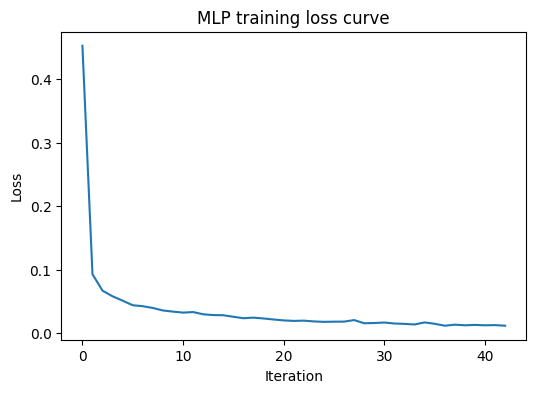

In [12]:
# Plot training loss if available
if HAS_MPL:
    loss_curve = mlp.named_steps['model'].loss_curve_
    plt.figure(figsize=(6, 4))
    plt.plot(loss_curve)
    plt.title('MLP training loss curve')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.show()
else:
    print('Matplotlib not available; skipping loss curve plot.')

## Model interpretability: permutation importance (model-agnostic)

Unlike tree-based models, MLPs do not provide a simple built-in notion of “feature importance.”

A practical workaround is **permutation importance**: shuffle one column at a time in the test set and measure how much the model’s score drops. If shuffling a feature hurts performance a lot, that feature is likely informative.

Important caveat:
- If two features are highly correlated, the model can “swap” between them. Permutation importance can underestimate importance in that case because shuffling one still leaves the other intact.

In [ ]:
# Compute permutation importances on a subset for speed
rng = np.random.default_rng(42)
subset_size = min(3000, len(X_test))
subset_idx = rng.choice(len(X_test), size=subset_size, replace=False)
X_test_sub = X_test.iloc[subset_idx]
y_test_sub_enc = y_test_enc.iloc[subset_idx]

result = permutation_importance(
    mlp, X_test_sub, y_test_sub_enc, n_repeats=3, random_state=42, n_jobs=-1
)
importances = pd.Series(result.importances_mean, index=features)
top = importances.sort_values(ascending=False).head(15)
print(top)

In [ ]:
# Optional bar plot of the top importances
if HAS_MPL:
    plt.figure(figsize=(7, 5))
    top.sort_values().plot(kind='barh')
    plt.title('Permutation importance (top features)')
    plt.xlabel('Mean accuracy drop when permuted')
    plt.tight_layout()
    plt.show()
else:
    print('Matplotlib not available; skipping importance plot.')

## What to try next (practical tuning ideas)

If you want to experiment further, here are safe, high-impact knobs:
- Change `hidden_layer_sizes`: try smaller networks (faster, less overfit) or larger (more capacity).
- Increase `alpha` if you suspect overfitting; decrease it if training underfits.
- Adjust `learning_rate_init` (e.g., `1e-4` or `3e-3`) if optimization is unstable/slow.
- Increase `max_iter` if the model stops too early without converging (watch `loss_curve_`).
- Consider feature engineering: log-transform heavy-tailed byte/packet counters, add ratios/asymmetry features, etc.

Deep learning is often less “plug-and-play” than tree models on tabular data, but it is a valuable tool when you have enough data and want a flexible non-linear model.